In [6]:
import sys
import os
import time

from SelfCal import PipelineWrapper
from SelfCal.SPHERExUtility import make_fiducial_chunk_map, make_fiducial_chunk_mask, \
load_calibration, make_spherex_offset_map, compute_offsets_guess, load_lvf_params, compute_column_adjacency, \
make_stripped_chunk_map, make_stripped_chunk_valid_mask, make_spherex_stripped_offset_map, fast_vertical_dist
from SelfCal.SPHERExAppendWav import wav_coadd

from astropy.io import fits
import numpy as np
import glob
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
mpl.rcParams['figure.dpi'] = 200
# Import LogNorm
from tqdm import tqdm
import gc
from functools import partial
import sys
import os
import shutil

from SelfCal.SPHERExUtility import load_calibration, load_lvf_params, compute_column_adjacency, \
make_stripped_chunk_map, make_stripped_chunk_valid_mask, make_spherex_stripped_offset_map, fast_vertical_dist
from SelfCal.SPHERExAppendWav import wav_coadd

In [7]:
def prepare_detector_inputs(frame_setting, mosaic_setting_oversample):
    detector = frame_setting['Detector']
    num_subchannels = frame_setting['NumSub']
    num_channels = frame_setting['NumCh']
    num_columns = frame_setting['NumCol']
    
    lvf_filename = f'lvf_params_D{detector}.npy'
    lvf_params = load_lvf_params(lvf_filename)

    det_BC, det_BW = load_calibration(band=detector, calibration_dir='/home/thomasli/spherex/SPHEREx_Spectral_Calibration')
    grid_chunk_map, _, _, _ = make_stripped_chunk_map(detector, num_subchannels=num_subchannels, num_channels=num_channels, num_columns=num_columns,
                                                    oversample_factor=mosaic_setting_oversample, lvf_params=lvf_params)
    det_chunk_map, _, r_edges, x_edges = make_stripped_chunk_map(detector, num_subchannels=num_subchannels, num_channels=num_channels, num_columns=num_columns,
                                            oversample_factor=1, lvf_params=lvf_params)
    
    adj_info = compute_column_adjacency(det_chunk_map, num_columns)
    # adj_info_subchannel = compute_subchannel_adjacency(det_chunk_map, num_columns)
    
    # adj_info = (
    #     np.concatenate([adj_info_column[0], adj_info_subchannel[0]]),
    #     np.concatenate([adj_info_column[1], adj_info_subchannel[1]])
    # )
        
    return {
        'lvf_params': lvf_params,
        'det_BC': det_BC,
        'det_BW': det_BW,
        'grid_chunk_map': grid_chunk_map,
        'det_chunk_map': det_chunk_map,
        'r_edges': r_edges,
        'x_edges': x_edges,
        'adj_info': adj_info
    }


def prepare_channel_inputs(ch, frame_setting, det_chunk_map, grid_chunk_map):
    num_subchannels = frame_setting['NumSub']
    num_channels = frame_setting['NumCh']
    num_columns = frame_setting['NumCol']
    
    chunk_valid_mask_padded = make_stripped_chunk_valid_mask(ch, num_subchannels=num_subchannels, num_channels=num_channels, 
                                        num_columns=num_columns, subchannel_padding=1)
    chunk_valid_mask = make_stripped_chunk_valid_mask(ch, num_subchannels=num_subchannels, num_channels=num_channels, 
                                        num_columns=num_columns, subchannel_padding=0)

    # Pre-calculate weights safely
    det_valid_mask = chunk_valid_mask_padded[det_chunk_map]
    det_valid_weight = fast_vertical_dist(det_valid_mask)
    if np.max(det_valid_weight) > 0:
        det_valid_weight /= np.max(det_valid_weight) 

    grid_valid_mask = chunk_valid_mask_padded[grid_chunk_map]
    grid_valid_weight = fast_vertical_dist(grid_valid_mask)
    if np.max(grid_valid_weight) > 0:
        grid_valid_weight /= np.max(grid_valid_weight) 

    return {
        'chunk_valid_mask_padded': chunk_valid_mask_padded,
        'chunk_valid_mask': chunk_valid_mask,
        'det_valid_mask': det_valid_mask,
        'grid_valid_mask': grid_valid_mask,
        'det_valid_weight': det_valid_weight,
        'grid_valid_weight': grid_valid_weight
    }

def mask_bright_pixels(local_vars):
    import numpy as np
    sub_data = local_vars['sub_data']
    sub_weight = local_vars['sub_weight']
    
    valid_mask = sub_weight > 0
    if np.sum(valid_mask) > 0:
        threshold = np.percentile(sub_data[valid_mask], 50)
        sub_weight[sub_data > threshold] = 0.0
        
    return sub_data

In [14]:
frame_setting = {
    'Detector': 4,
    'NumSub': 10,
    'NumCh': 34,
    'NumCol': 5,
}

selfcal_config = PipelineWrapper.PipelineConfig(
    output_dir='/mnt/md124/thomasli/selfcal/outputs/',
    run_name=f'SPHEREx_nep_qr2_det{frame_setting["Detector"]}_6p2arcsec',
    resolution_arcsec=6.2
)

calibration_kwargs = {
    'apply_mask': True,
    'apply_weight': False,
    'outlier_thresh': 2.0,
    'ignore_list': [],
    'batch_size': 40,
    'offset_regularization': True,
    'reg_weight': 10.0,
    'weighted_damping': True,
    'damp_weight': 100.0,
    'max_workers': 30,
    'postprocess_func': None,#mask_bright_pixels
}

lsqr_kwargs = {
    'atol': 1e-06,
    'btol': 1e-06,
    'damp': 1e-3,
    'iter_lim': 100,
    'precondition': False
}

mosaic_kwargs = {
    'apply_mask': True,
    'apply_weight': False,
    'make_std_map': False,
    'apply_sigma_clipping': False,
    'sigma': 1.0,
    'ignore_list': [21],
    'cache_batch_size': 40,
    'coadd_batch_size': 100,
    'cache_intermediate': False,
    'max_workers': 50
}

mosaic_oversample_factor = 2

CACHE_DIR = '/home/thomasli/spherex/selfcal/cache/'
FILE_SUFFIX = f'_subchannelReg_test'

# Channels to process
ch = [23]

In [12]:
frame_setting_str = '_'.join([f'{key}{value}' for key, value in frame_setting.items()])

# 1. Prepare overarching detector inputs
detector_inputs = prepare_detector_inputs(frame_setting, mosaic_oversample_factor)

job_name = f'Ch{"-".join(map(str, ch))}'
print(f"Processing channel {job_name} for detector {frame_setting['Detector']}...")

job_tag = f'{frame_setting_str}_{job_name}{FILE_SUFFIX}'
cal_file = f'cal_{job_tag}.h5'
mos_file = f"mosaic_{job_tag}.fits"
cache_dir = f'{CACHE_DIR}cache_{job_tag}'

# Prepare specific inputs for this channel
channel_inputs = prepare_channel_inputs(ch, frame_setting, detector_inputs['det_chunk_map'], detector_inputs['grid_chunk_map'])


Loaded LVF parameters from /home/thomasli/spherex/selfcal/selfcal_scripts/lvf_params/lvf_params_D4.npy


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 341/341 [00:10<00:00, 32.64it/s]


Computing Vertical Strip Adjacency (Filtering Arcs)...
Found 1367 vertical strip boundaries.
Processing channel Ch23 for detector 4...


In [ ]:
cc = PipelineWrapper.Calibrator(selfcal_config)

cc.setup_lsqr(
    chunk_map=detector_inputs['det_chunk_map'],
    grid_valid_weight=channel_inputs['det_valid_mask'],
    oversample_factor=1,
    adj_info=detector_inputs['adj_info'],
    **calibration_kwargs
)

cc.apply_lsqr(**lsqr_kwargs)
cal_path = cc.save_calibration(cal_file=cal_file)

In [45]:
cal_path = '/mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/calibration/cal_Detector4_NumSub10_NumCh34_NumCol3_Ch23_100Damp_10Reg_noSubReg_brightPixelMask.h5'

In [46]:
mm = PipelineWrapper.Mosaicker(selfcal_config)
mm.load_calibration(cal_path=cal_path)

# maps = mm.make_mosaic(
#     chunk_map=detector_inputs['grid_chunk_map'],
#     grid_valid_weight=channel_inputs['grid_valid_weight'],
#     oversample_factor=mosaic_oversample_factor,
#     det_offset_func=None,
#     cache_dir=cache_dir,
#     **mosaic_kwargs
# )

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 13184/13184 [00:00<00:00, 1240053.46it/s]

Loading reference frame from: /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/ref.fits
Calibration loaded from /mnt/md124/thomasli/selfcal/outputs/SPHEREx_nep_qr2_det4_6p2arcsec/calibration/cal_Detector4_NumSub10_NumCh34_NumCol3_Ch23_100Damp_10Reg_noSubReg_brightPixelMask.h5


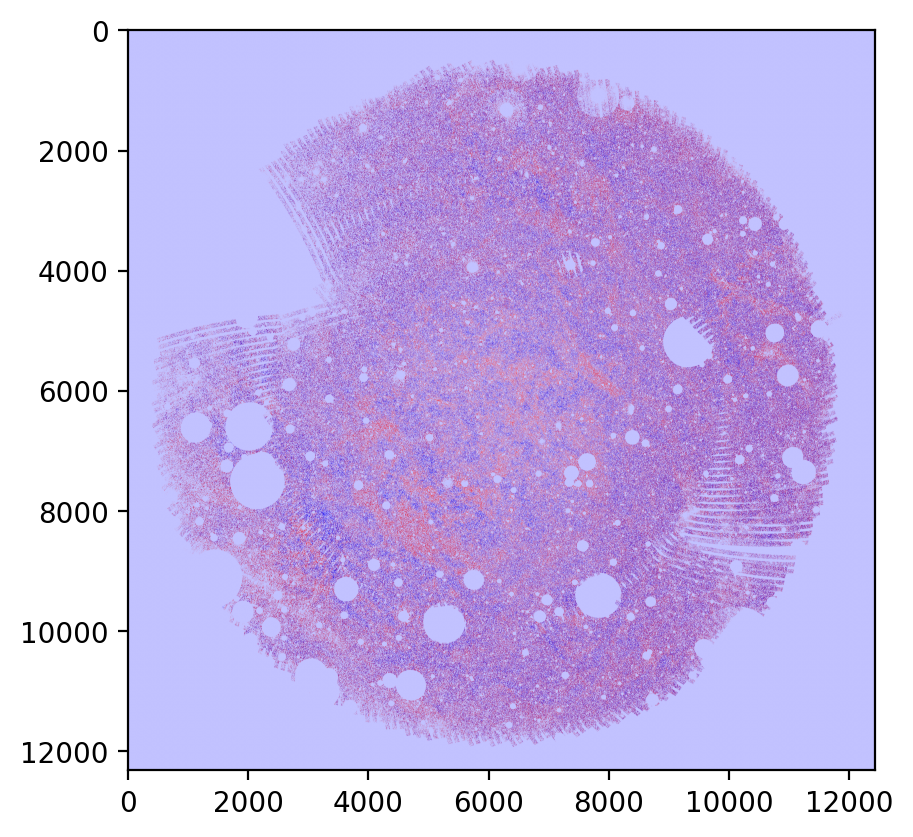

In [47]:
skymap = mm.skymap
vmin, vmax = np.nanpercentile(skymap[np.nonzero(skymap)], [25, 75])
plt.imshow(skymap, vmin=vmin, vmax=vmax, cmap='bwr')

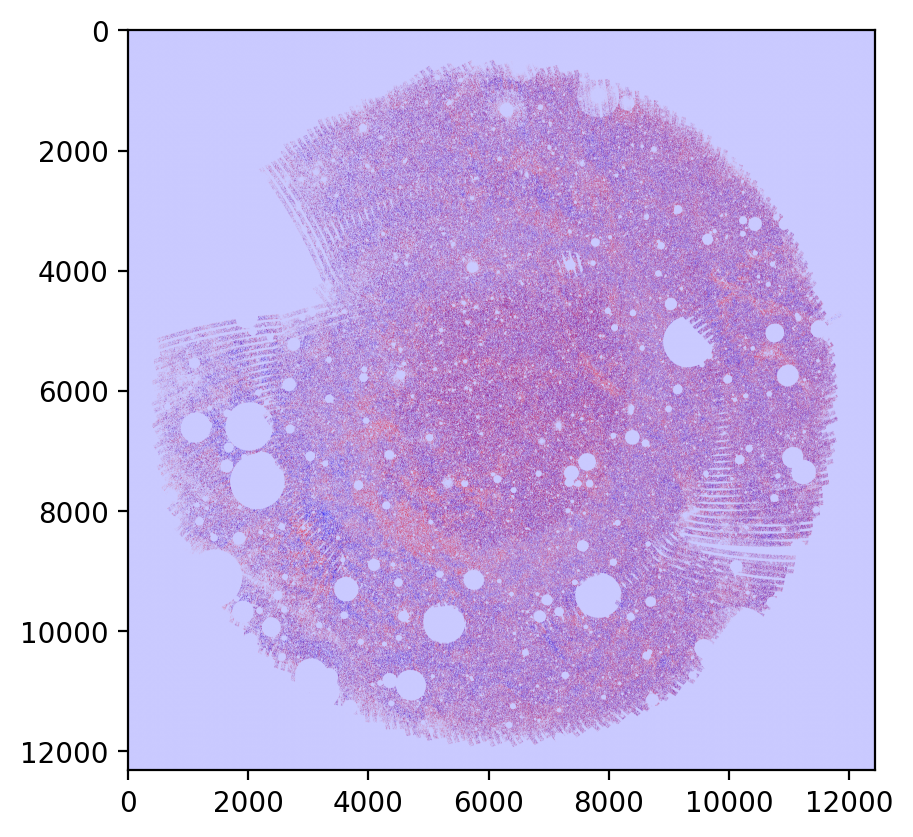

In [44]:
skymap = mm.skymap
vmin, vmax = np.nanpercentile(skymap[np.nonzero(skymap)], [25, 75])
plt.imshow(skymap, vmin=vmin, vmax=vmax, cmap='bwr')

In [18]:
mosaic = mm.maps['mean_map']['data']

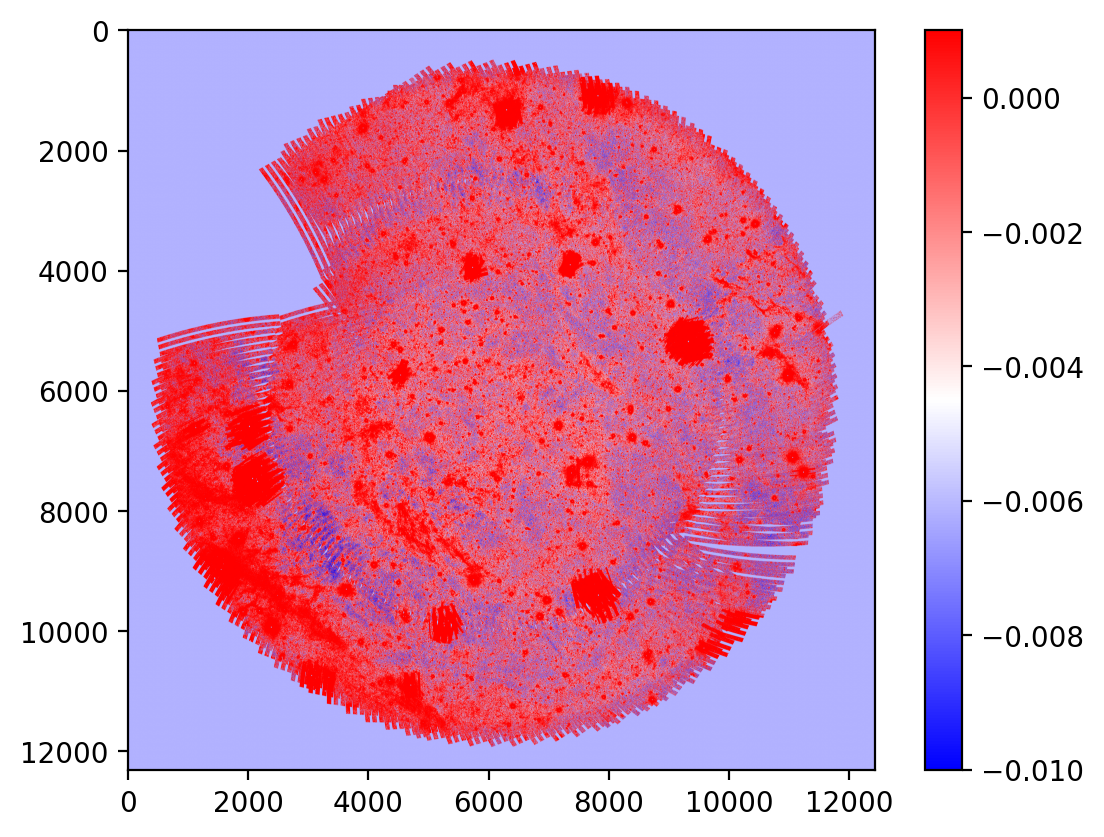

In [19]:
plt.imshow(mosaic-np.nanmedian(mosaic[np.nonzero(mosaic)]), vmin=-0.01, vmax=0.001, cmap='bwr')
plt.colorbar()